# Train an MLP baseline on IBL Brain Wide Map data

In this notebook we train a **Multi-Layer Perceptron (MLP)** from scratch to decode animal behavior
(e.g. wheel velocity) spiking activity in relevant brain areas.

**Experiment**: we train three separate models, each restricted to a different subset of
units selected by brain region:
- **motor** — primary and secondary motor cortex units
- **caudoputamen** — striatal units
- **both** — motor + caudoputamen combined

**Notebook outline:**

1. **Dataset** — Load the processed HDF5 recordings (produced by the previous pipeline notebook) and set up train / validation / test `DataLoader`s.
2. **Register the output modality** — Declare `wheel_velocity` as the decoding target in the `torch_brain` modality registry.
3. **Hyperparameters** — Set binning resolution, window length, model size, and training constants.
4. **Train one MLP per brain-region subset** — Filter units by area, build a separate `MLPNeuralDecoder` for each region subset, and train with a standard MSE loop.
5. **Test set evaluation and comparison** — Run inference on held-out data, compute Pearson r per interval, and compare the three models with violin plots and time-series visualizations.



In [1]:
from pathlib import Path
import numpy as np
import torch
import torch_brain
from torch_brain.registry import MODALITY_REGISTRY, DataType
from torch_brain.transforms import UnitFilter, Compose

from mlp import MLPNeuralDecoder
from aux_functions import (
    get_loaders,
    get_unit_ids,
    move_to_device,
    pearson_r,
    compute_r2,
    training_step,
    plot_training_curves,
    plot_test_intervals,
)

## 1. Dataset and Dataloaders

The processed neural recordings were produced in the previous notebook using the `brainsets` pipeline, which downloads the raw IBL Brain Wide Map sessions from DANDI and converts them into structured HDF5 files stored under `ibl_processed/`. Each file corresponds to one recording session and contains:

- **Spike times** and **unit metadata** (brain area, quality score, waveform statistics) for all Neuropixels-sorted units
- **Behavioral signals** such as wheel velocity, wheel position, and pose-estimation keypoints
- **Trial table** with per-trial event timestamps (stimulus onset, movement onset, feedback)
- **Pre-defined time domains** for the `train`, `valid`, and `test` splits (70/10/20 random-trial split, seeded for reproducibility)
- **Task-aligned intervals** — short time windows anchored to specific behavioral events, used to select the appropriate input spiking times (see below)

### `torch_brain` Dataset and DataLoader

`torch_brain` provides a structured `Dataset` class that lazily loads HDF5 files and exposes each recording as a `temporaldata.Data` object. The `IBLBrainWideMapDataset` class (defined in `aux_functions.py`) extends it with:

- **`SpikingDatasetMixin`** — automatically handles spike-time namespacing across sessions so that unit IDs from different animals remain globally unique.
- **`get_recording_hook`** — injects a per-recording `config` dict that carries the readout modality name and normalization statistics into every data slice.
- **`get_sampling_intervals`** — returns a dict mapping each recording ID to an `Interval` object that defines *where* the sampler is allowed to draw windows.

The `torch_brain` samplers (`RandomFixedWindowSampler`, `SequentialFixedWindowSampler`) operate on these intervals: they tile or randomly sample fixed-length windows within the allowed regions and yield `(recording_id, start_time, end_time)` tuples to the `DataLoader`.

`get_loaders` (in `aux_functions.py`) wires everything together:
1. Computes normalization statistics from the training portion of the data.
2. Creates a **single shared `IBLBrainWideMapDataset`** — the same object is used by all three loaders, so swapping `dataset.transform` affects train, val, and test simultaneously.
3. Creates three samplers — `RandomFixedWindowSampler` for train, `SequentialFixedWindowSampler` for val and test — each receiving the appropriate split's sampling intervals.
4. Wraps them in standard PyTorch `DataLoader`s with `collate` from `torch_brain.data`.

### Task-aligned sampling

Beyond the global split domains, the pipeline stores **task-aligned intervals** for each session: short time windows anchored to specific behavioral events. Passing `task` to `get_loaders` computes the **intersection** of each split's time domain with the corresponding task-aligned windows, so the sampler only draws windows from periods where the chosen event occurred.

| `task` value | Reference event | Window | Use case |
|---|---|---|---|
| `"stimulus_side"` | Gabor stimulus onset | [−0.9 s, +0.1 s] | Decode stimulus side |
| `"stimulus_contrast"` | Gabor stimulus onset | [−0.9 s, +0.1 s] | Decode stimulus contrast |
| `"choice"` | Wheel movement onset | [0 s, +1 s] | Decode which direction the mouse turned |
| `"reward"` | Feedback delivery | [0 s, +1 s] | Decode trial outcome |
| `"wheel_movement"` | Gabor stimulus onset | [0 s, +1 s] | Decode kinematics during the response period |
| `None` | — | Full trial window | No event alignment (default) |

<figure>
  <img src="images/interval_alignment.png" width="800"/>
  <figcaption>Figure 1: Task-aligned intervals.</figcaption>
</figure>

In [2]:
# List of recording IDs to use (h5 file stems, without the .h5 extension)
recording_ids = [
    #"sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys",
    #"sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys",
    "sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys",
    #"sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys",
    #"sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys",
    #"sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys",
    #"sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys",
    #"sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-e56541a5-a6d5-4750-b1fe-f6b5257bfe7c_desc-processed_behavior+ecephys",
]

dir_path = Path(".").resolve()

dataset, train_loader, val_loader, test_loader = get_loaders(
    dir_path=dir_path,
    recording_ids=recording_ids,
    readout_id="wheel_velocity",
    task="wheel_movement",
    window_length=1.0,
    batch_size=16,
)

print(f"Recordings  : {len(dataset.recording_ids)}")
print(f"Total units : {len(dataset.get_unit_ids())}")

Recordings  : 1
Total units : 2856


## 2. Register the output modality

`torch_brain` uses a global modality registry to declare what a model should predict: the
attribute paths in the data where target values and their timestamps live, the output dimension,
and the loss function. Here we register `wheel_velocity` as a 1-D continuous signal decoded
with MSE loss.

The resulting `readout_spec` is passed to `MLPNeuralDecoder` to configure its output layer and
to `model.tokenize` to know which field to extract from each data slice. The `if` guard makes
the cell safe to re-run without raising a duplicate-registration error.

In [3]:
# Only register if not already registered (safe for re-running the cell)
if "wheel_velocity" not in MODALITY_REGISTRY:
    torch_brain.register_modality(
        name="wheel_velocity",
        dim=1,
        type=DataType.CONTINUOUS,
        timestamp_key="wheel_velocity.timestamps",
        value_key="wheel_velocity.values",
        loss_fn=torch_brain.nn.loss.MSELoss(),
    )

readout_spec = MODALITY_REGISTRY["wheel_velocity"]
print(readout_spec)

ModalitySpec(id=20, dim=1, type=<DataType.CONTINUOUS: 0>, timestamp_key='wheel_velocity.timestamps', value_key='wheel_velocity.values', loss_fn=MSELoss())


## 3. Hyperparameters

The following constants control the model architecture and training:

- **`BIN_SIZE`** — Width of each spike-count bin on the input side (10 ms → 100 bins per second of recording).
- **`SEQUENCE_LENGTH`** — Duration of each training/evaluation window in seconds.
- **`READOUT_RATE`** — Native sampling rate of the wheel velocity signal in Hz; sets the number of output prediction steps per window.
- **`HIDDEN_DIM`** — Number of neurons in the MLP hidden layer.
- **`NUM_EPOCHS`** — Number of full passes over the training set.
- **`LR`** — Learning rate for the AdamW optimizer.
- **`QUALITY_SCORE`** — IBL single-unit quality threshold; only units above this value are included when filtering by brain region in Section 4.

In [4]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda:0") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

BIN_SIZE        = 10e-3    # 10 ms  → 100 input bins / second
SEQUENCE_LENGTH = 1.0      # 1-second context window
READOUT_RATE    = 1000.0   # Hz  → 1000 output steps / second
HIDDEN_DIM      = 256
NUM_EPOCHS      = 20
LR              = 1e-4
QUALITY_SCORE   = 0.6      # IBL quality score threshold

Using device: mps


## 4. Train one MLP per brain-region subset

We train **three separate MLP models**, each receiving spikes from a different subset of
recorded units selected by brain region:

| Experiment | Region filter | Key question |
|---|---|---|
| **4a. motor** | Primary & secondary motor cortex | Motor cortex alone is sufficient to decode wheel velocity? |
| **4b. caudoputamen** | Striatum (caudoputamen) | Striatal activity also encodes wheel kinematics? |
| **4c. both** | Motor + caudoputamen combined | Does adding more regions improve decoding? |

Unlike POYO — which uses an infinite-vocabulary unit embedding and can handle any set of units at
inference time — the MLP bakes `num_units` directly into its first linear layer. This means the unit count must be fixed before the model is constructed.

The workflow for each experiment is therefore:

1. `get_unit_ids(dataset, filter_str=..., quality_score=...)` → list of valid unit IDs, given the filter parameters
2. `UnitFilter(mask_fn=..., field="spikes", reset_index=True)` → drops unwanted units and
   remaps `spikes.unit_index` to `0 … N_filtered-1`
3. `MLPNeuralDecoder(num_units=N_filtered, ...)` → model parametrized for that unit count
4. `dataset.transform = Compose([unit_filter, model.tokenize])` → apply filter then tokenize
5. Standard training loop with `training_step` / `compute_r2`

Results are stored in shared dicts (`trained_models`, `unit_filters`, …) for the comparison in
Section 5.

In [5]:
# Shared containers — populated by each sub-section below
trained_models   = {}   # label -> trained MLPNeuralDecoder
unit_filters     = {}   # label -> UnitFilter transform
r2_logs_by_exp   = {}   # label -> val R² log (for training curves)
loss_logs_by_exp = {}   # label -> training loss log

### 4a. Motor cortex

Units in **primary and secondary motor cortex** (location name contains `"motor"`). These areas
are directly involved in planning and executing voluntary movements, so we expect a strong
correlation with wheel velocity.

In [6]:
LABEL = "motor"
FILTER_STRS = ["motor"]

# 1. Filter unit IDs by region and quality
unit_ids_motor = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Motor units (quality > {QUALITY_SCORE}): {len(unit_ids_motor)}")

# 2. Build UnitFilter — keeps only selected units, remaps spike indices
valid_set_motor = set(unit_ids_motor)
unit_filter_motor = UnitFilter(
    mask_fn=lambda units, vs=valid_set_motor: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_motor

# 3. Build MLP with the filtered unit count
model_motor = MLPNeuralDecoder(
    num_units=len(unit_ids_motor),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()

# 4. Chain transforms: filter → tokenize
dataset.transform = Compose([unit_filter_motor, model_motor.tokenize])

# 5. Train
opt_motor = torch.optim.AdamW(model_motor.parameters(), lr=LR)
r2_log_motor, loss_log_motor = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_motor)
    r2_log_motor.append(val_r2)

    model_motor.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_motor, opt_motor)
        loss_log_motor.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_motor)
r2_log_motor.append(final_r2)
print(f"✅ Motor — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_motor
r2_logs_by_exp[LABEL]   = r2_log_motor
loss_logs_by_exp[LABEL] = loss_log_motor

Motor units (quality > 0.6): 160
  Epoch   1/20  loss=2.1896  val_R²=-0.002
  Epoch   2/20  loss=1.9027  val_R²=0.029
  Epoch   3/20  loss=1.2251  val_R²=0.205
  Epoch   4/20  loss=0.8466  val_R²=0.367
  Epoch   5/20  loss=0.6383  val_R²=0.388
  Epoch   6/20  loss=0.5087  val_R²=0.414
  Epoch   7/20  loss=0.4325  val_R²=0.423
  Epoch   8/20  loss=0.3629  val_R²=0.426
  Epoch   9/20  loss=0.2988  val_R²=0.434
  Epoch  10/20  loss=0.2541  val_R²=0.438
  Epoch  11/20  loss=0.2174  val_R²=0.441
  Epoch  12/20  loss=0.1865  val_R²=0.445
  Epoch  13/20  loss=0.1630  val_R²=0.447
  Epoch  14/20  loss=0.1432  val_R²=0.451
  Epoch  15/20  loss=0.1266  val_R²=0.452
  Epoch  16/20  loss=0.1138  val_R²=0.453
  Epoch  17/20  loss=0.1035  val_R²=0.454
  Epoch  18/20  loss=0.0953  val_R²=0.456
  Epoch  19/20  loss=0.0883  val_R²=0.454
  Epoch  20/20  loss=0.0876  val_R²=0.454
✅ Motor — final val R² = 0.453


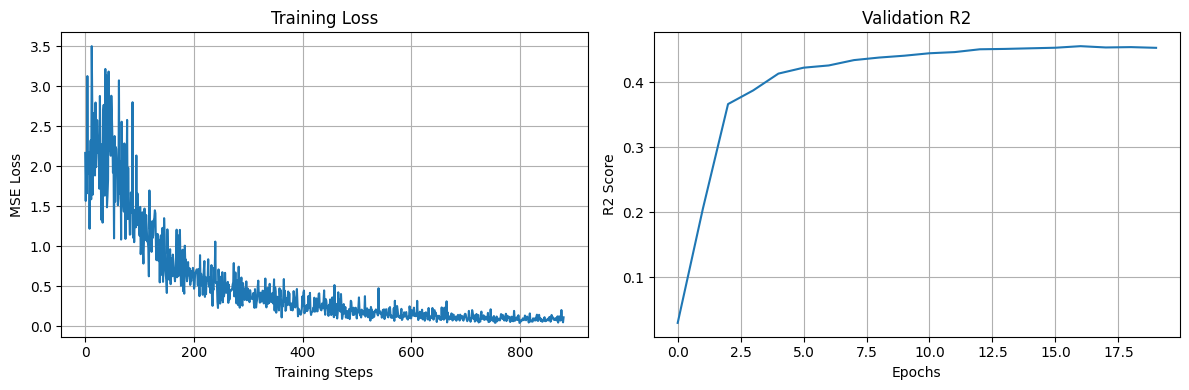

In [7]:
plot_training_curves(r2_log_motor, loss_log_motor)

### 4b. Caudoputamen (striatum)

Units in the **caudoputamen** — the dorsal striatum. This region is part of the basal ganglia
and is involved in action selection and motor control. It receives strong projections from motor
cortex, so its activity may also correlate with wheel kinematics.

In [8]:
LABEL = "caudoputamen"
FILTER_STRS = ["caudoputamen"]

unit_ids_cp = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Caudoputamen units (quality > {QUALITY_SCORE}): {len(unit_ids_cp)}")

valid_set_cp = set(unit_ids_cp)
unit_filter_cp = UnitFilter(
    mask_fn=lambda units, vs=valid_set_cp: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_cp

model_cp = MLPNeuralDecoder(
    num_units=len(unit_ids_cp),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()

dataset.transform = Compose([unit_filter_cp, model_cp.tokenize])

opt_cp = torch.optim.AdamW(model_cp.parameters(), lr=LR)
r2_log_cp, loss_log_cp = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_cp)
    r2_log_cp.append(val_r2)

    model_cp.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_cp, opt_cp)
        loss_log_cp.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_cp)
r2_log_cp.append(final_r2)
print(f"✅ Caudoputamen — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_cp
r2_logs_by_exp[LABEL]   = r2_log_cp
loss_logs_by_exp[LABEL] = loss_log_cp

Caudoputamen units (quality > 0.6): 283
  Epoch   1/20  loss=2.1452  val_R²=-0.002
  Epoch   2/20  loss=1.5267  val_R²=0.103
  Epoch   3/20  loss=0.9465  val_R²=0.380
  Epoch   4/20  loss=0.6831  val_R²=0.488
  Epoch   5/20  loss=0.5286  val_R²=0.529
  Epoch   6/20  loss=0.4311  val_R²=0.549
  Epoch   7/20  loss=0.3472  val_R²=0.565
  Epoch   8/20  loss=0.2815  val_R²=0.577
  Epoch   9/20  loss=0.2356  val_R²=0.582
  Epoch  10/20  loss=0.2014  val_R²=0.592
  Epoch  11/20  loss=0.1737  val_R²=0.597
  Epoch  12/20  loss=0.1528  val_R²=0.601
  Epoch  13/20  loss=0.1353  val_R²=0.603
  Epoch  14/20  loss=0.1202  val_R²=0.608
  Epoch  15/20  loss=0.1070  val_R²=0.606
  Epoch  16/20  loss=0.0965  val_R²=0.609
  Epoch  17/20  loss=0.0916  val_R²=0.607
  Epoch  18/20  loss=0.0881  val_R²=0.610
  Epoch  19/20  loss=0.0817  val_R²=0.610
  Epoch  20/20  loss=0.0801  val_R²=0.611
✅ Caudoputamen — final val R² = 0.612


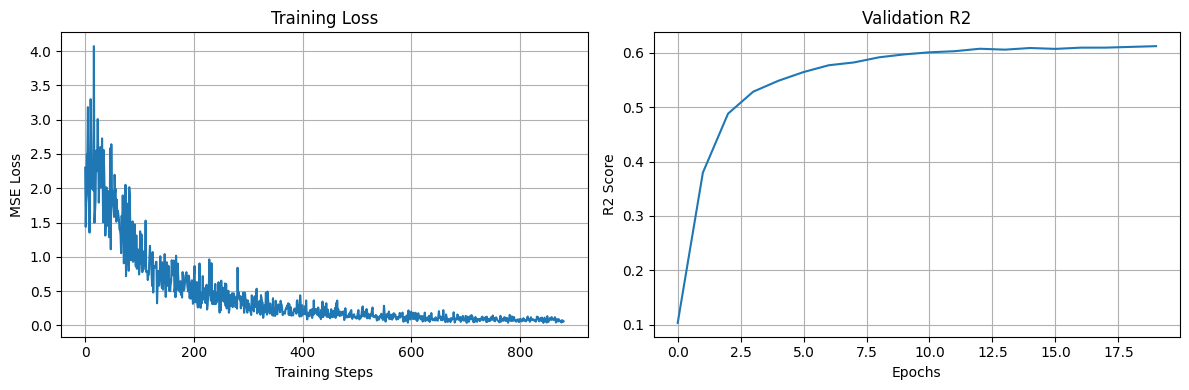

In [9]:
plot_training_curves(r2_log_cp, loss_log_cp)

### 4c. Both regions combined

Combine all **motor cortex + caudoputamen** units into a single input. With more units the
model's input layer is larger (`num_input_bins × (N_motor + N_cp)`), giving it access to
complementary signals from both regions.

In [10]:
LABEL = "both"
FILTER_STRS = ["motor", "caudoputamen"]

unit_ids_both = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Motor + caudoputamen units (quality > {QUALITY_SCORE}): {len(unit_ids_both)}")

valid_set_both = set(unit_ids_both)
unit_filter_both = UnitFilter(
    mask_fn=lambda units, vs=valid_set_both: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_both

model_both = MLPNeuralDecoder(
    num_units=len(unit_ids_both),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()

dataset.transform = Compose([unit_filter_both, model_both.tokenize])

opt_both = torch.optim.AdamW(model_both.parameters(), lr=LR)
r2_log_both, loss_log_both = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_both)
    r2_log_both.append(val_r2)

    model_both.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_both, opt_both)
        loss_log_both.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_both)
r2_log_both.append(final_r2)
print(f"✅ Both — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_both
r2_logs_by_exp[LABEL]   = r2_log_both
loss_logs_by_exp[LABEL] = loss_log_both

Motor + caudoputamen units (quality > 0.6): 443
  Epoch   1/20  loss=2.1278  val_R²=-0.002
  Epoch   2/20  loss=1.4228  val_R²=0.112
  Epoch   3/20  loss=0.8081  val_R²=0.429
  Epoch   4/20  loss=0.5601  val_R²=0.496
  Epoch   5/20  loss=0.4391  val_R²=0.545
  Epoch   6/20  loss=0.3476  val_R²=0.558
  Epoch   7/20  loss=0.2782  val_R²=0.567
  Epoch   8/20  loss=0.2248  val_R²=0.586
  Epoch   9/20  loss=0.1854  val_R²=0.592
  Epoch  10/20  loss=0.1566  val_R²=0.595
  Epoch  11/20  loss=0.1331  val_R²=0.601
  Epoch  12/20  loss=0.1152  val_R²=0.603
  Epoch  13/20  loss=0.1024  val_R²=0.606
  Epoch  14/20  loss=0.0950  val_R²=0.609
  Epoch  15/20  loss=0.0868  val_R²=0.609
  Epoch  16/20  loss=0.0808  val_R²=0.606
  Epoch  17/20  loss=0.0739  val_R²=0.607
  Epoch  18/20  loss=0.0630  val_R²=0.609
  Epoch  19/20  loss=0.0564  val_R²=0.611
  Epoch  20/20  loss=0.0509  val_R²=0.610
✅ Both — final val R² = 0.610


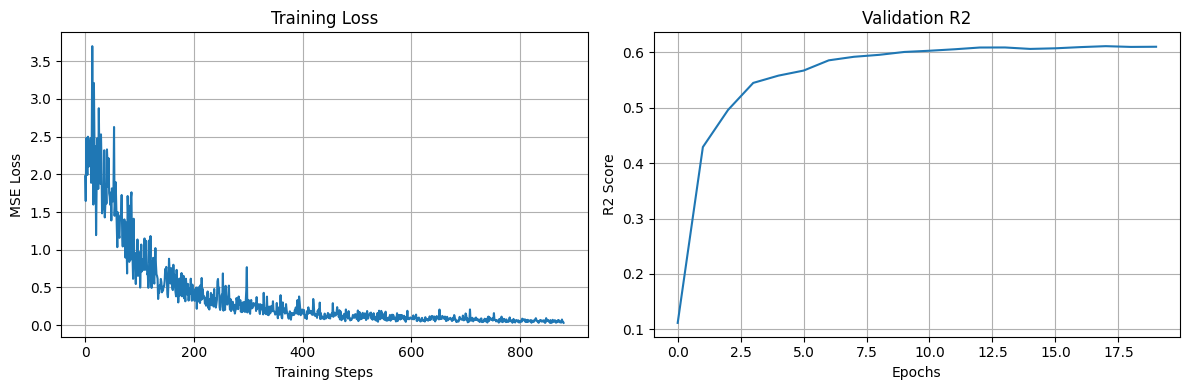

In [11]:
plot_training_curves(r2_log_both, loss_log_both)

## 5. Test set evaluation and comparison

With the three models trained, we now evaluate them on held-out **test data** — a portion of
the recording that was never seen during training or validation.

For each model the appropriate `UnitFilter + tokenize` transform is re-applied to the shared
dataset, inference is run over all test windows, and **Pearson r** is computed per 1-second
interval. Results are then compared across models with a violin plot of the per-interval r
distribution and side-by-side time-series plots of the best and worst decoded intervals.

In [12]:
test_results = {}  # label -> {targets, preds, r2_scores}

for label, m in trained_models.items():
    m.eval()
    # Restore the unit filter + tokenize transform for this model
    dataset.transform = Compose([unit_filters[label], m.tokenize])

    targets, preds, r2_scores = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch  = move_to_device(batch, device)
            pred   = m(**batch["model_inputs"]).squeeze(-1)   # (B, T_out)
            target = batch["target_values"]                    # (B, T_out)

            for i in range(pred.shape[0]):
                r = pearson_r(pred[i], target[i])
                preds.append(pred[i])
                targets.append(target[i])
                r2_scores.append(r.item())

    median_r2 = float(np.nanmedian(r2_scores))
    mean_r2   = float(np.nanmean(r2_scores))
    print(f"{label:15s}  Test R²  median={median_r2:.3f}   mean={mean_r2:.3f}")
    test_results[label] = dict(targets=targets, preds=preds, r2_scores=r2_scores)

motor            Test R²  median=0.712   mean=0.586
caudoputamen     Test R²  median=0.835   mean=0.696
both             Test R²  median=0.841   mean=0.697


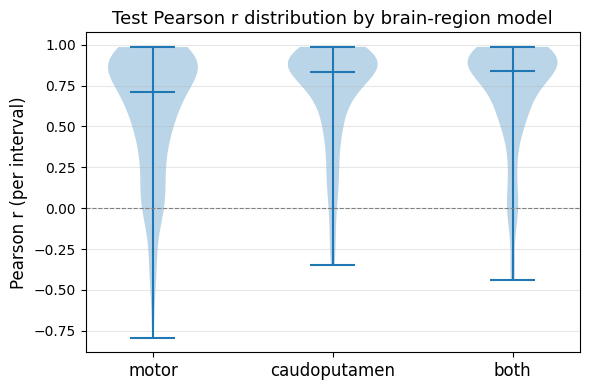

motor            n= 200  median=0.712  mean=0.586  std=0.388
caudoputamen     n= 200  median=0.835  mean=0.696  std=0.314
both             n= 200  median=0.841  mean=0.697  std=0.332


In [13]:
# Summary: R² distribution per brain-region model
import matplotlib.pyplot as plt

labels = list(test_results.keys())
r2_data = [
    np.array(test_results[lb]["r2_scores"])
    for lb in labels
]
# Remove NaN for cleaner plots
r2_clean = [arr[~np.isnan(arr)] for arr in r2_data]

fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot(r2_clean, showmedians=True, showextrema=True)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=12)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Pearson r (per interval)", fontsize=12)
ax.set_title("Test Pearson r distribution by brain-region model", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for lb, arr in zip(labels, r2_clean):
    print(f"{lb:15s}  n={len(arr):4d}  "
          f"median={np.median(arr):.3f}  mean={np.mean(arr):.3f}  std={np.std(arr):.3f}")

Let's visualize how each model performs in decoding the wheel velocity. Intervals with significant wheel movement are relatively well decoded by the models, with marginal improvement when combining units from both regions. The models fail to decode low or no movement intervals.

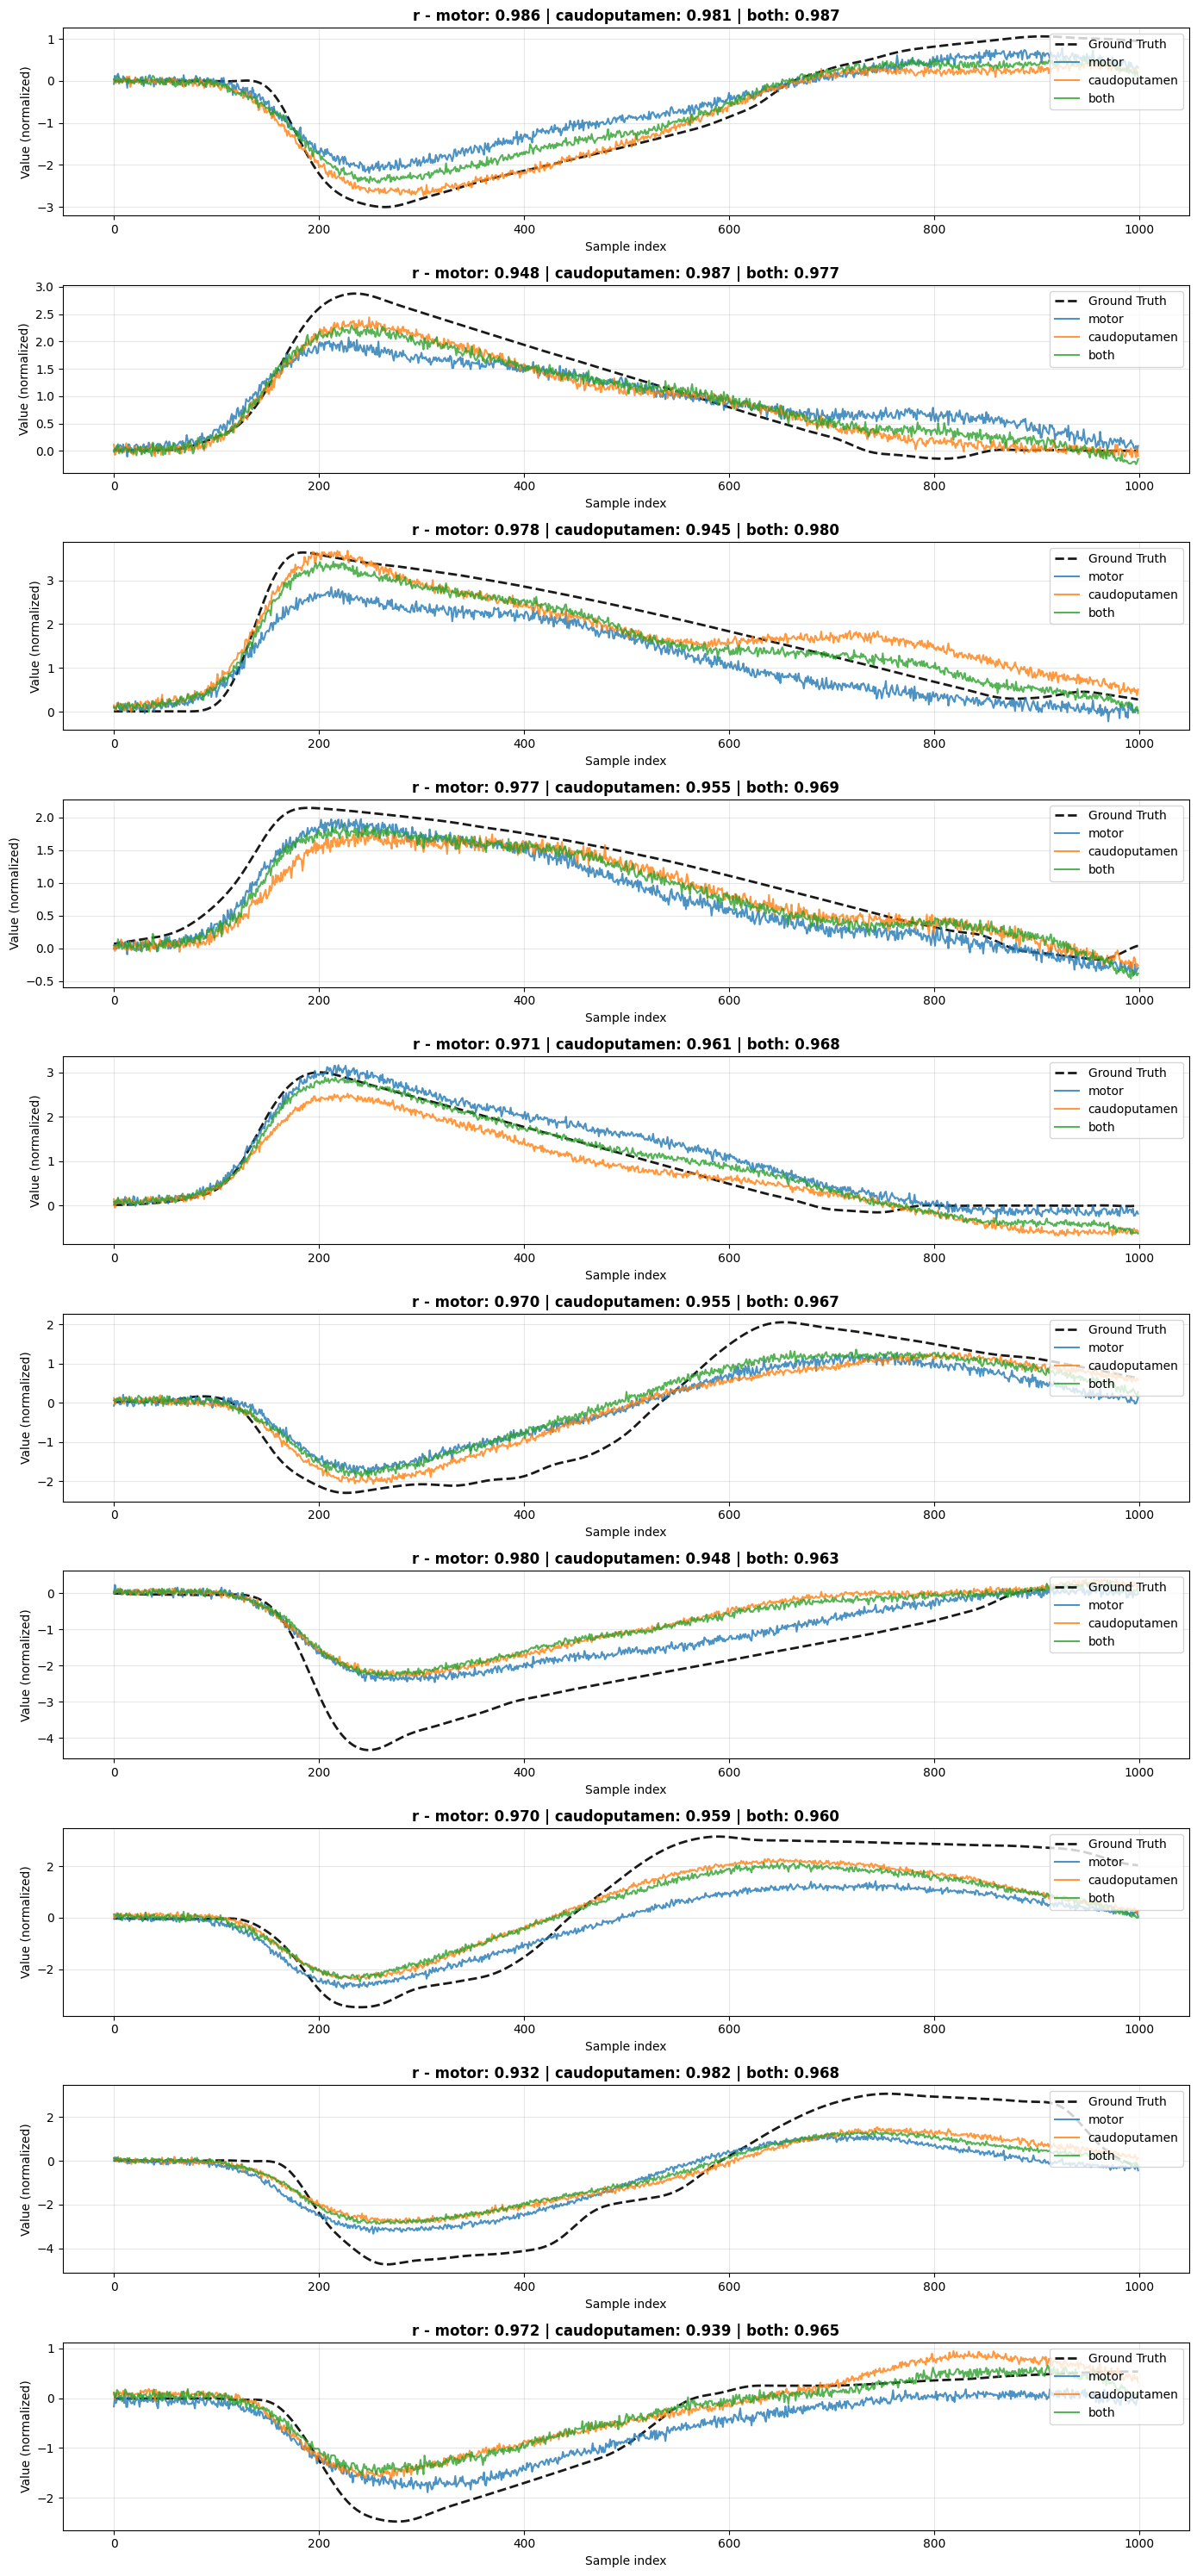

In [14]:
plot_test_intervals(
    test_results=test_results,
    n_intervals=10,
    order="top",
)

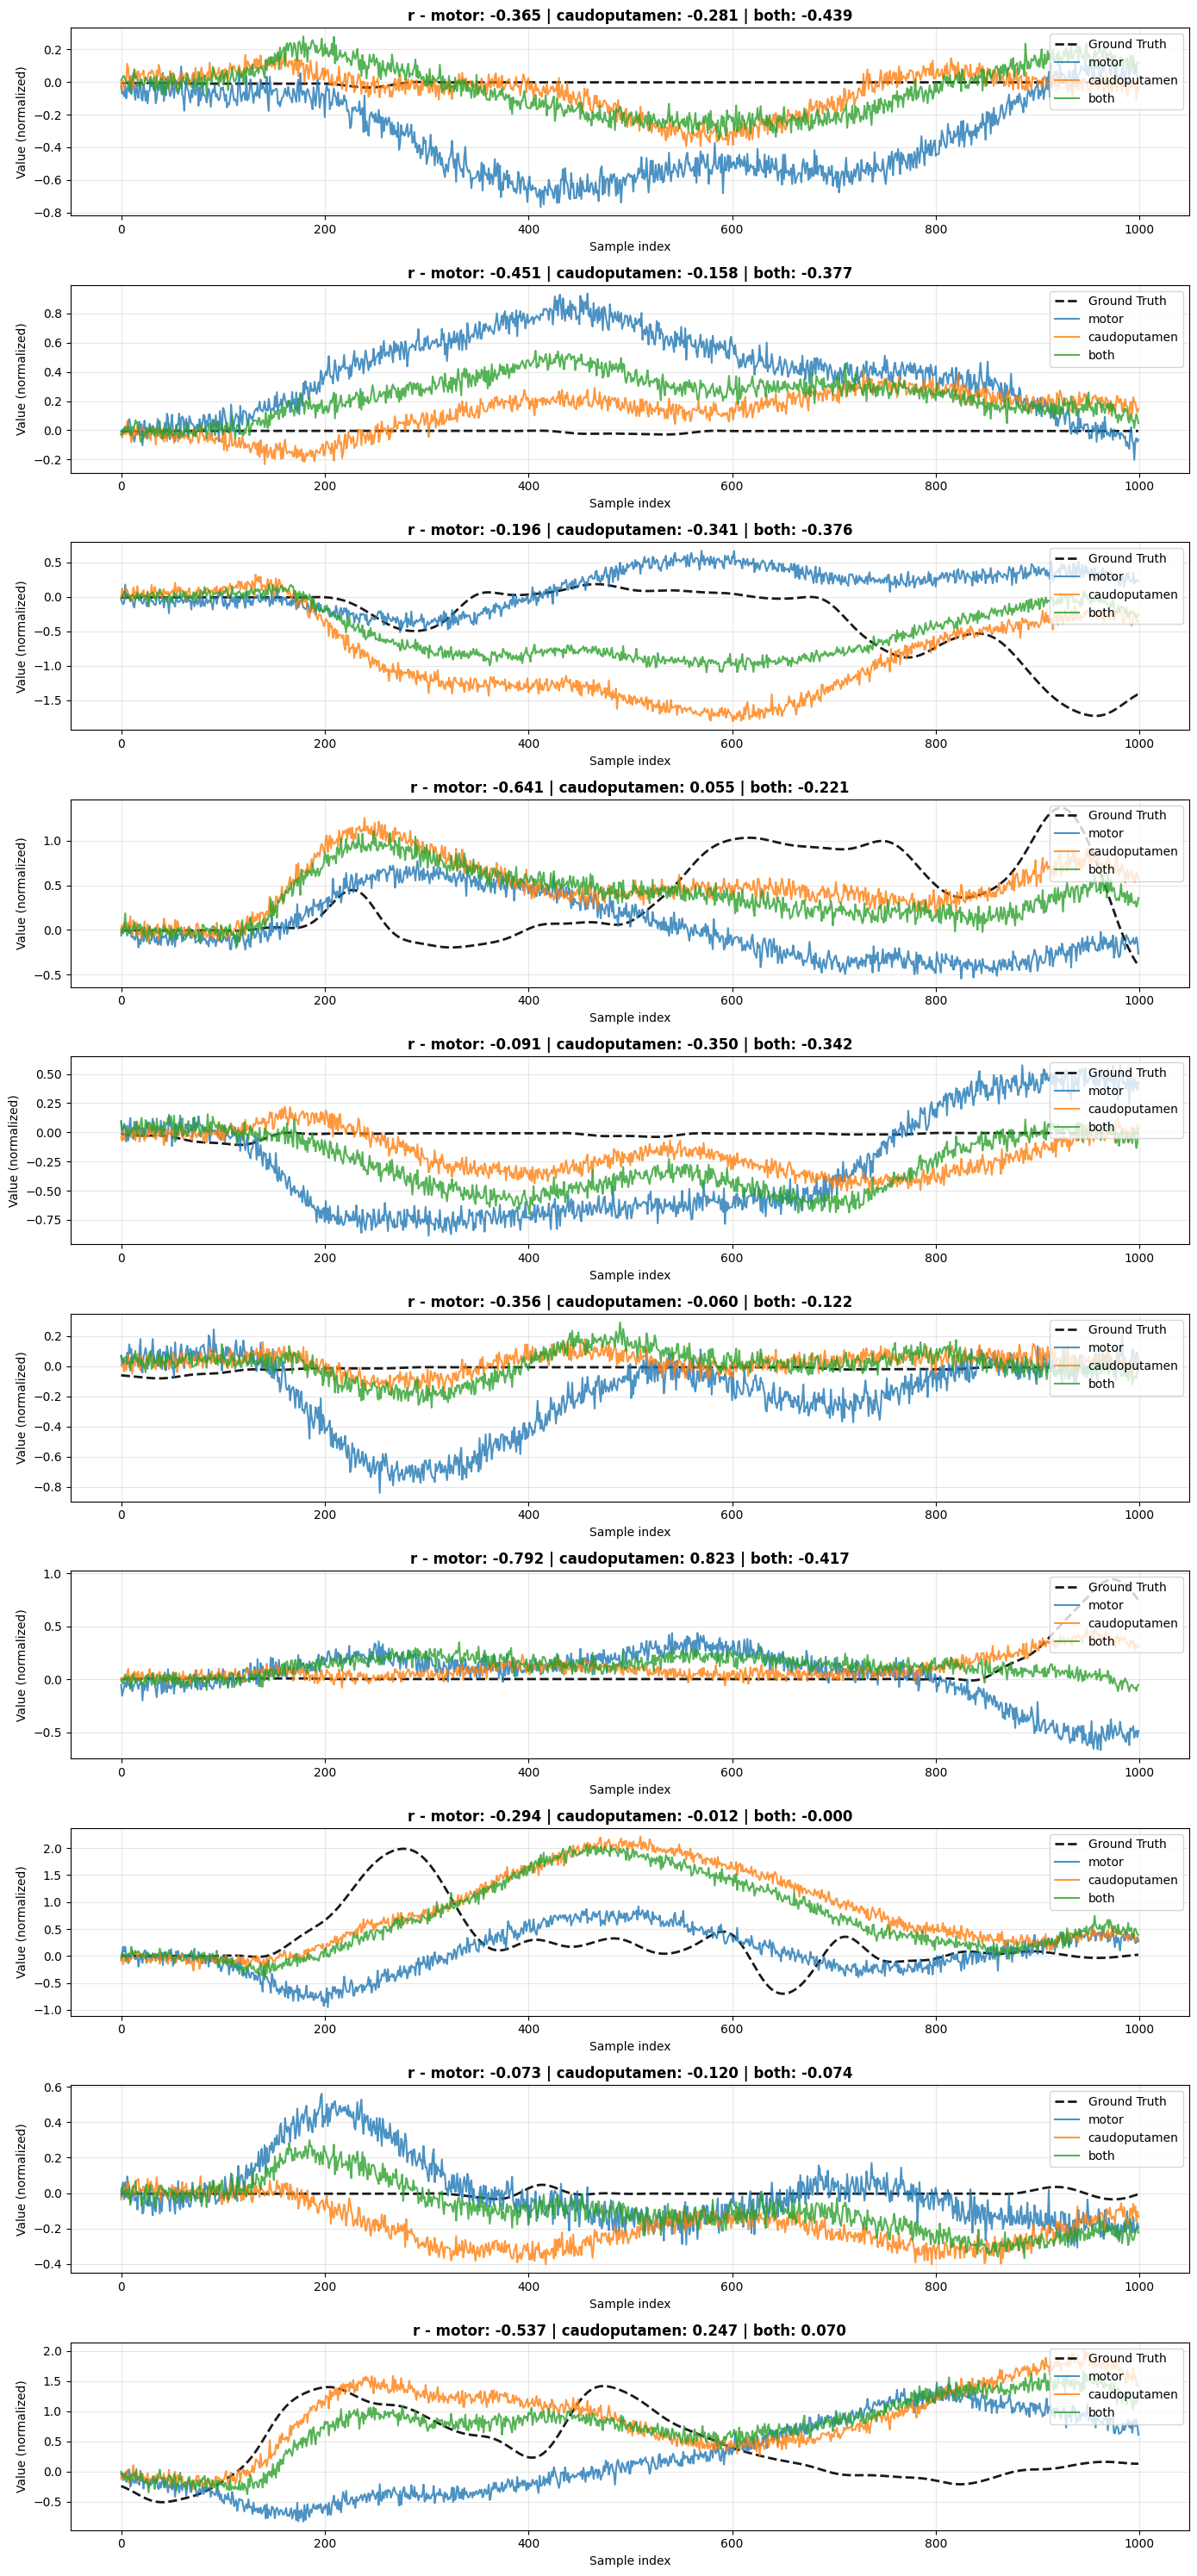

In [15]:
plot_test_intervals(
    test_results=test_results,
    n_intervals=10,
    order="bottom",
)